In [ ]:
from typing import TypedDict
from langchain_groq import ChatGroq
from langchain_core.prompts import PromptTemplate
from pydantic import BaseModel
from langgraph.graph import StateGraph , START , END
from tavily import TavilyClient

class BlogState(TypedDict):
    topic : str
    research_required : bool
    research_result : str

In [18]:

class router_class(BaseModel):
    research_required : bool

def router(state : BlogState) -> BlogState:
    llm = ChatGroq(
        api_key="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",
        model="openai/gpt-oss-120b",
    )

    structured_llm = llm.with_structured_output(
        router_class,
        method='json_mode'
        # method controls whether LangChain uses tools, JSON forcing, or schema validation to make the model return structured output.

        # function_calling → force via tools
        # json_mode → force via API format
        # json_schema → force via strict validation
        )
    
    prompt = PromptTemplate(
        template="""You are a router.

Topic: {topic}

Decide whether external research is required.

IMPORTANT:
- Output MUST be valid JSON
- Do NOT return anything except JSON

Format:
{{
    "research_required": true or false
}}
""",
        input_variables=['topic'],
        # partial_variables={'format_instructions' : parser.get_format_instructions()}
        # when using with_structured_output , u dont need parsers and partial_variables usually.

    )

    chain = prompt | structured_llm

    result = chain.invoke({'topic' : state['topic']})

    return {'research_required' : result.research_required}


In [19]:
def classify_node(state : BlogState) -> BlogState:
    if state['research_required'] == True:
        return "research"
    else: 
        return "orchestrator"

In [ ]:
def research(state: BlogState) -> BlogState:
    
    client = TavilyClient("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")
    response = client.search(
    query=state['topic'],
    search_depth="advanced"
)
    return {'research_result' : response}

def orchestrator(state: BlogState) -> BlogState:
    
    llm = ChatGroq(
        api_key="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",
        model="openai/gpt-oss-120b",
    )

    prompt = PromptTemplate(
        template=""""""
    )

    return state

In [21]:
graph = StateGraph(BlogState)

graph.add_node('router', router)
graph.add_node('research' , research)
graph.add_node('orchestrator' , orchestrator)


graph.add_edge(START , 'router')
graph.add_conditional_edges(
    'router',
    classify_node,
    {
        "research" : "research",
        "orchestrator" : "orchestrator"
    }
)

graph.add_edge("research" , END)
graph.add_edge("orchestrator" , END)

workflow = graph.compile()

initial_state = {
    'topic' : 'self-attention'
}




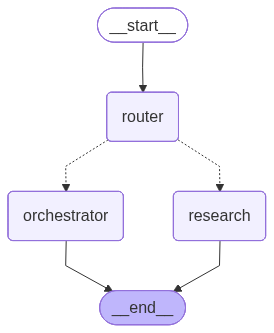

In [22]:
workflow

In [23]:
workflow.invoke(initial_state)
# 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

Generating blog...


{'topic': 'self-attention', 'research_required': False}